# Day 4: Enrichment & Expression Analysis
## Bioinformatics Course - IMBB-FORTH

### Objectives

- Understand enrichment analysis through a concrete toy example
- Compare gene expression between conditions
- Identify differentially expressed genes
- See how enrichment applies to GO terms

---

## 1. Setup

In [14]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import hypergeom
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Base URL for loading data from anywhere
REPO = "https://raw.githubusercontent.com/cgenomicslab/imbb-data-analysis/main"

print("Libraries loaded.")

Libraries loaded.


---

## 2. Enrichment: Colored Balls Example

Imagine a bag with **100 balls** of 5 colors:

| Color | Count |
|-------|-------|
| Purple | 20 |
| Red | 30 |
| Blue | 25 |
| Green | 15 |
| Yellow | 10 |

You grab a **subset of 15 balls** and count: **8 are purple**.

Purple is 20% of the bag, so you'd expect about 3 purple in 15 draws. But you got 8.

**Is purple enriched in your subset, or was it just luck?**

### The concept

The large circle is the **population**. The small circle is our **subset**. Notice how purple is over-represented in the subset.

![Population of balls](../data/enrichment_schema.png "Coloured balls")

### Expected vs Observed

In [15]:
# The population
population = ['purple'] * 20 + ['red'] * 30 + ['blue'] * 25 + ['green'] * 15 + ['yellow'] * 10

# What we observed in our subset of 15
observed = {'purple': 8, 'red': 3, 'blue': 2, 'green': 1, 'yellow': 1}
subset_size = 15

# How many of each color in the full bag
bag = {'purple': 20, 'red': 30, 'blue': 25, 'green': 15, 'yellow': 10}

# Compare expected vs observed
print("Color", "\t", "Expected", "\t", "Observed", "\t", "Fold enrichment")
print("-" * 48)
for color in bag:
    exp = subset_size * bag[color] / 100
    obs = observed[color]
    fold = obs / exp
    print(color, "\t", round(exp, 1), "\t", obs, "\t", round(fold, 2))

Color 	 Expected 	 Observed 	 Fold enrichment
------------------------------------------------
purple 	 3.0 	 8 	 2.67
red 	 4.5 	 3 	 0.67
blue 	 3.8 	 2 	 0.53
green 	 2.2 	 1 	 0.44
yellow 	 1.5 	 1 	 0.67


### Is it significant? Permutation test

Same logic as Day 3: randomly grab 15 balls from the bag thousands of times. How often do we get ≥8 purple?

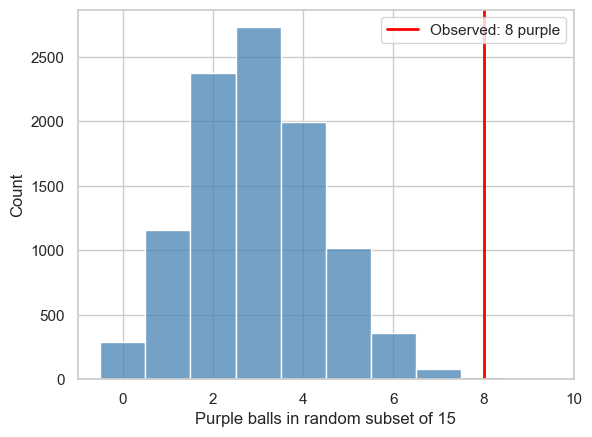

P-value: 0.0018


In [16]:
# Permutation test
np.random.seed(42)
n_permutations = 10000
purple_counts = []

for i in range(n_permutations):
    random_grab = np.random.choice(population, size=subset_size, replace=False)
    purple_counts.append(np.sum(random_grab == 'purple'))

purple_counts = np.array(purple_counts)

# Plot
sns.histplot(purple_counts, bins=range(0, 13), discrete=True, color='steelblue')
plt.axvline(8, color='red', linewidth=2, label='Observed: 8 purple')
plt.xlabel('Purple balls in random subset of 15')
plt.legend()
plt.show()

p_perm = np.sum(purple_counts >= 8) / n_permutations
print("P-value:", p_perm)

### The hypergeometric test

The [hypergeometric distribution](https://en.wikipedia.org/wiki/Hypergeometric_distribution) calculates the exact probability of drawing a certain number of "special" items from a population **without replacement**.

It takes four numbers:
- **M**: total population (100 balls)
- **n**: special items in population (20 purple)
- **N**: how many we drew (15)
- **k**: special items we observed (8)

This is the standard test used in GO enrichment tools.

In [17]:
# Hypergeometric test: exact p-value
p_hyper = hypergeom.sf(7, M=100, n=20, N=15)  # P(X >= 8)

print("Permutation p-value:   ", p_perm)
print("Hypergeometric p-value:", round(p_hyper, 4))
print()
print("Both agree: purple is significantly enriched.")

Permutation p-value:    0.0018
Hypergeometric p-value: 0.0018

Both agree: purple is significantly enriched.


### 💡 Exercise 4.1: Test All Colors

**Task:** For each color, calculate the fold enrichment and hypergeometric p-value.
Which colors are enriched? Which are depleted?

In [18]:
# Test all colors
print("Color      Obs   Exp   Fold   P-value    Enriched?")
print("-" * 52)

for color in bag:
    obs = observed[color]
    exp = subset_size * bag[color] / 100
    fold = round(obs / exp, 2)
    
    # Hypergeometric test for enrichment
    p = hypergeom.sf(obs - 1, M=100, n=bag[color], N=subset_size)
    
    sig = 'Yes' if p < 0.05 else 'No'
    print(color, "     ", obs, "  ", round(exp, 1), " ", fold, "  ", round(p, 4), "    ", sig)

Color      Obs   Exp   Fold   P-value    Enriched?
----------------------------------------------------
purple       8    3.0   2.67    0.0018      Yes
red       3    4.5   0.67    0.8928      No
blue       2    3.8   0.53    0.9357      No
green       1    2.2   0.44    0.929      No
yellow       1    1.5   0.67    0.8192      No


---

## 3. Differential Expression

Now let's work with gene expression data.

We have RNA-seq counts for 100 genes measured in 9 samples from 3 conditions:
Normal, Treatment_A, and Treatment_B (3 replicates each).

**The question:** Which genes change between conditions?

### Load the data

In [19]:
# Load expression data (samples in rows, genes in columns)
expression = pd.read_csv(REPO + '/data/bulk_rnaseq_counts.csv', index_col=0)
metadata = pd.read_csv(REPO + '/data/bulk_rnaseq_metadata.csv')

print("Expression:", expression.shape[0], "samples ×", expression.shape[1], "genes")
expression.head()

Expression: 9 samples × 100 genes


,Gene_001,Gene_002,Gene_003,Gene_004,Gene_005,Gene_006,Gene_007,Gene_008,Gene_009,Gene_010,...,Gene_091,Gene_092,Gene_093,Gene_094,Gene_095,Gene_096,Gene_097,Gene_098,Gene_099,Gene_100
sample,,,,,,,,,,,,,,,,,,,,,
Normal_Rep1,147,199,164,139,335,252,120,134,113,135,...,153,145,172,140,175,187,144,295,138,224
Normal_Rep2,143,256,221,139,254,275,151,170,111,137,...,169,153,153,154,127,223,133,237,140,201
Normal_Rep3,92,223,186,109,241,295,141,176,84,149,...,185,214,154,191,159,195,92,325,153,257
Treatment_A_Rep1,628,591,998,669,1666,1206,551,394,453,543,...,143,150,197,194,138,219,143,294,146,170
Treatment_A_Rep2,657,1234,709,614,1494,842,506,510,396,555,...,173,140,194,167,136,207,148,211,146,196


In [20]:
metadata

,sample_name,condition,replicate
0,Normal_Rep1,Normal,Rep1
1,Normal_Rep2,Normal,Rep2
2,Normal_Rep3,Normal,Rep3
3,Treatment_A_Rep1,Treatment_A,Rep1
4,Treatment_A_Rep2,Treatment_A,Rep2
5,Treatment_A_Rep3,Treatment_A,Rep3
6,Treatment_B_Rep1,Treatment_B,Rep1
7,Treatment_B_Rep2,Treatment_B,Rep2
8,Treatment_B_Rep3,Treatment_B,Rep3


### Look at a single gene

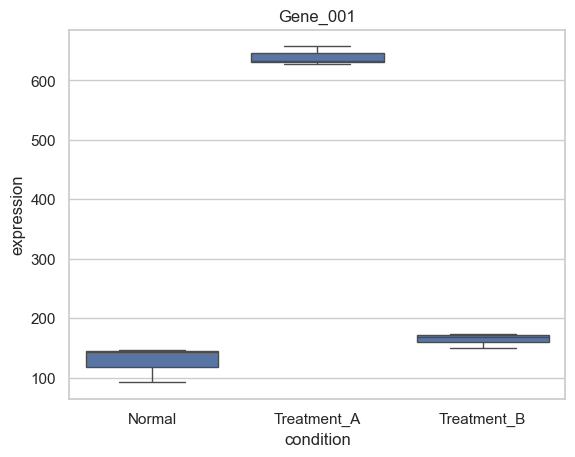

Gene_001 is clearly higher in Treatment_A.


In [21]:
# Boxplot of Gene_001 across conditions
gene = 'Gene_001'

plot_data = pd.DataFrame({
    'expression': expression[gene].values,
    'condition': metadata['condition'].values
})

sns.boxplot(data=plot_data, x='condition', y='expression')
plt.title(gene)
plt.show()

print(gene, "is clearly higher in Treatment_A.")

### Test a single gene

We use the t-test from Day 3 to check if the difference is significant.

In [22]:
# Get expression values for each condition
normal_samples = metadata[metadata['condition'] == 'Normal']['sample_name'].values
treat_a_samples = metadata[metadata['condition'] == 'Treatment_A']['sample_name'].values

gene = 'Gene_001'
normal_vals = expression.loc[normal_samples, gene]
treat_a_vals = expression.loc[treat_a_samples, gene]

# Fold change
fold_change = treat_a_vals.mean() / normal_vals.mean()

# T-test
t_stat, p_value = stats.ttest_ind(normal_vals, treat_a_vals)

print(gene)
print("  Normal mean:     ", round(normal_vals.mean()))
print("  Treatment_A mean:", round(treat_a_vals.mean()))
print("  Fold change:     ", round(fold_change, 2))
print("  P-value:         ", round(p_value, 6))

Gene_001
  Normal mean:      127
  Treatment_A mean: 639
  Fold change:      5.02
  P-value:          1.3e-05


### Test all genes

Now we loop through all 100 genes.

In [23]:
# Test all genes: Normal vs Treatment_A
results = []

for gene in expression.columns:
    normal_vals = expression.loc[normal_samples, gene]
    treat_a_vals = expression.loc[treat_a_samples, gene]
    
    fc = treat_a_vals.mean() / normal_vals.mean()
    log2_fc = np.log2(fc)
    t, p = stats.ttest_ind(normal_vals, treat_a_vals)
    
    results.append({'gene': gene, 'log2_fc': log2_fc, 'p_value': p})

results_df = pd.DataFrame(results)
print("Tested", len(results_df), "genes")
results_df.head()

Tested 100 genes


,gene,log2_fc,p_value
0,Gene_001,2.327958,0.000013
1,Gene_002,1.861059,0.045651
2,Gene_003,2.089987,0.002890
3,Gene_004,2.345591,0.000024
4,Gene_005,2.429737,0.000336


### How many are differentially expressed?

In [24]:
# Significant genes
de_genes = results_df[(results_df['p_value'] < 0.05) & (results_df['log2_fc'].abs() > 1)]

up = de_genes[de_genes['log2_fc'] > 0]
down = de_genes[de_genes['log2_fc'] < 0]

print("Differentially expressed (p < 0.05 and |fold change| > 2):", len(de_genes))
print("  Upregulated:  ", len(up))
print("  Downregulated:", len(down))

Differentially expressed (p < 0.05 and |fold change| > 2): 30
  Upregulated:   15
  Downregulated: 15


In [25]:
# Top 10 most significant
top = results_df.sort_values('p_value').head(10)

print("Gene         Log2 FC    P-value      Direction")
print("-" * 48)
for _, row in top.iterrows():
    direction = 'Up' if row['log2_fc'] > 0 else 'Down'
    print(row['gene'], "   ", round(row['log2_fc'], 2), "      ", round(row['p_value'], 6), "   ", direction)

Gene         Log2 FC    P-value      Direction
------------------------------------------------
Gene_010     2.0        5e-06     Up
Gene_012     2.17        1e-05     Up
Gene_001     2.33        1.3e-05     Up
Gene_004     2.35        2.4e-05     Up
Gene_026     -1.88        0.000215     Down
Gene_023     -2.26        0.000259     Down
Gene_017     -2.04        0.000268     Down
Gene_005     2.43        0.000336     Up
Gene_009     1.97        0.000486     Up
Gene_014     2.26        0.000536     Up


### 💡 Exercise 4.2: Visualize a DE Gene

**Task:** Pick one of the top DE genes from the table above.
1. Create a boxplot of its expression across all 3 conditions
2. Is it also different in Treatment_B compared to Normal?

In [26]:
# Your code here
gene = # Pick a gene from the top list

plot_data = pd.DataFrame({
    'expression': expression[gene].values,
    'condition': metadata['condition'].values
})

# Boxplot
# Your code


SyntaxError: invalid syntax (32827264.py, line 2)

---

## 4. GO Enrichment: From Balls to Biology

We found a list of upregulated genes. Now we ask: **do they share a biological function?**

This is the same enrichment question as the colored balls:

| Balls example | GO enrichment |
|---|---|
| 100 balls in a bag | All genes in the genome |
| Purple, red, blue... | GO categories (metabolism, signal transduction...) |
| Subset of 15 balls | Our DE gene list |
| "Is purple enriched?" | "Is signal transduction enriched?" |

We have a table that tells us which genes belong to which GO categories.

### Load GO annotations

In [27]:
# Load gene-to-GO mapping
go_table = pd.read_csv(REPO + '/data/go_annotations.csv')

print("GO annotations:", len(go_table), "rows")
print()
print("GO categories:")
print(go_table['go_name'].value_counts())
print()
go_table.head(10)

GO annotations: 65 rows

GO categories:
go_name
metabolism             17
signal_transduction    15
cell_cycle             14
immune_response        11
apoptosis               8
Name: count, dtype: int64



,gene,go_term,go_name
0,Gene_001,GO:0007165,signal_transduction
1,Gene_001,GO:0008152,metabolism
2,Gene_002,GO:0006915,apoptosis
3,Gene_002,GO:0008152,metabolism
4,Gene_003,GO:0007165,signal_transduction
5,Gene_003,GO:0008152,metabolism
6,Gene_004,GO:0007165,signal_transduction
7,Gene_005,GO:0007165,signal_transduction
8,Gene_005,GO:0008152,metabolism
9,Gene_006,GO:0007049,cell_cycle


### Which GO terms do our upregulated genes belong to?

In [28]:
# Our upregulated genes
up_genes = list(de_genes[de_genes['log2_fc'] > 0]['gene'].values)
print("Upregulated genes:", up_genes)

# For each GO term: how many of our genes are in it?
total_genes = len(expression.columns)  # all genes in our dataset
list_size = len(up_genes)

print()
print("Total genes in dataset:", total_genes)
print("Upregulated genes:", list_size)
print()

print("GO term                  In list   In genome   Expected   Fold    P-value    Enriched?")
print("-" * 85)

for go_name in go_table['go_name'].unique():
    # Genes in this GO category
    go_genes = go_table[go_table['go_name'] == go_name]['gene'].unique()
    category_size = len(go_genes)
    
    # How many of our upregulated genes are in this category?
    overlap = len(set(up_genes) & set(go_genes))
    expected = list_size * category_size / total_genes
    fold = round(overlap / expected, 2) if expected > 0 else 0
    
    # Hypergeometric test
    p = hypergeom.sf(overlap - 1, M=total_genes, n=category_size, N=list_size)
    sig = 'Yes' if p < 0.05 else 'No'
    
    print(go_name, " " * (24 - len(go_name)), overlap, "       ", category_size, "        ",
          round(expected, 1), "     ", fold, "   ", round(p, 4), "     ", sig)

Upregulated genes: ['Gene_001', 'Gene_002', 'Gene_003', 'Gene_004', 'Gene_005', 'Gene_006', 'Gene_007', 'Gene_008', 'Gene_009', 'Gene_010', 'Gene_011', 'Gene_012', 'Gene_013', 'Gene_014', 'Gene_015']

Total genes in dataset: 100
Upregulated genes: 15

GO term                  In list   In genome   Expected   Fold    P-value    Enriched?
-------------------------------------------------------------------------------------
signal_transduction       11         15          2.2       4.89     0.0       Yes
metabolism                7         17          2.5       2.75     0.0035       Yes
apoptosis                 1         8          1.2       0.83     0.7414       No
cell_cycle                2         14          2.1       0.95     0.6632       No
immune_response           0         11          1.6       0.0     1.0       No


### Interpretation

The upregulated genes are enriched for **signal transduction** — the same logic as the purple balls.

In a real analysis, tools like [Enrichr](https://maayanlab.cloud/Enrichr/), [g:Profiler](https://biit.cs.ut.ee/gprofiler/), or [DAVID](https://david.ncifcrf.gov/) do this automatically across thousands of GO categories.

### 💡 Exercise 4.3: Downregulated Genes

**Task:** Repeat the GO enrichment, but for the **downregulated** genes.
Which GO term is enriched this time?

In [29]:
# Your code here
down_genes = list(de_genes[de_genes['log2_fc'] < 0]['gene'].values)
print("Downregulated genes:", down_genes)

# Test each GO term
# Your code


Downregulated genes: ['Gene_016', 'Gene_017', 'Gene_018', 'Gene_019', 'Gene_020', 'Gene_021', 'Gene_022', 'Gene_023', 'Gene_024', 'Gene_025', 'Gene_026', 'Gene_027', 'Gene_028', 'Gene_029', 'Gene_030']


---

## Summary

### Enrichment
- **Enrichment = observed vs expected** in a subset
- **Permutation test** — simulate random subsets to estimate significance
- **Hypergeometric test** — exact calculation ([Wikipedia](https://en.wikipedia.org/wiki/Hypergeometric_distribution))
- Same logic applies to colored balls and to GO terms

### Differential expression
- For each gene: **fold change** (how much) + **p-value** (is it real)
- Filter by both significance and effect size

### Workflow
1. Compare conditions → find DE genes
2. Take DE gene list → test for GO enrichment
3. Interpret: what biological functions are affected?

### Tomorrow: Day 5

We'll explore **dimensionality reduction**:
- PCA on a toy dataset to build intuition
- PCA on expression data
- UMAP visualization